## This notebook tests if the hydrologic indices of gauges with shorter time series differ from longer time series by comparing gauges that are form the same region and regulation level

In [1]:
import pandas as pd 
import geopandas as gpd

import numpy as np

from scipy import stats
from scipy.spatial.distance import cdist

import os


In [2]:
# The functions are AI generated, they have been checked and modifeied to work as expected by a human

def find_n_closest_points(
    distance_df: pd.DataFrame,
    point_idx: str,
    n: int,
    subset_indices: list = None,
    exclude_self: bool = True
) -> pd.Series:
    """
    Find the n closest points to a given point in a distance matrix.

    Parameters:
    -----------
    distance_df : pd.DataFrame
        A square distance matrix where rows and columns are indices of points.
    point_idx : int
        The index of the reference point.
    n : int
        Number of closest points to return.
    subset_indices : list, optional
        If provided, only consider points in this list.
    exclude_self : bool, default=True
        If True, excludes the reference point itself from results.

    Returns:
    --------
    pd.Series
        A Series of the n closest point indices, sorted by distance.

    """
    # Validate inputs
    if point_idx not in distance_df.index:
        raise ValueError(f"Point index {point_idx} not found in distance matrix.")

    if subset_indices is not None:
        subset_indices = [idx for idx in subset_indices if idx in distance_df.index]
        if point_idx not in subset_indices:
            subset_indices.append(point_idx)  # Ensure reference point is included
        distances = distance_df.loc[point_idx, subset_indices]
    else:
        distances = distance_df.loc[point_idx]

    # Sort distances and get closest points
    sorted_distances = distances.sort_values()

    # Exclude the point itself if requested
    if exclude_self:
        sorted_distances = sorted_distances[sorted_distances.index != point_idx]

    # Return top n closest points
    return sorted_distances.head(n)

def compute_point_vs_subset_variation(
    df: pd.DataFrame,
    point_idx: str,
    subset_indices: list,
    variation_metric: str = "std"  # Options: "std", "var", "range", "mad"
) -> pd.Series:
    """
    Compute variation between a chosen point and a subset of points.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame where rows are point IDs and columns are features.
    point_idx : int
        Index of the reference point.
    subset_indices : list
        List of indices defining the subset of points.
    variation_metric : str, default="std"
        Metric to compute variation ("std", "var", "range", "mad").

    Returns:
    --------
    pd.Series
        Variation between the point and subset for each feature.
    """
    if point_idx not in df.index:
        raise ValueError(f"Point {point_idx} not found in DataFrame.")

    subset = df.loc[subset_indices]
    point_values = df.loc[[point_idx]]
    values = pd.concat([subset, point_values])

    if variation_metric == "std":
        variation = values.std()
    elif variation_metric == "var":
        variation = (point_values - subset.mean()).abs() / np.sqrt(subset.var())
    elif variation_metric == "range":
        variation = (point_values - subset.mean()).abs() / (subset.max() - subset.min())
    elif variation_metric == "mad":
        variation = (point_values - subset.median()).abs() / subset.mad()
    else:
        raise ValueError("Invalid variation_metric. Use 'std', 'var', 'range', or 'mad'.")

    return variation

def compute_subset_internal_variation(
    df: pd.DataFrame,
    subset_indices: list,
    variation_metric: str = "std"  # Options: "std", "var", "range", "mad"
) -> pd.Series:
    """
    Compute internal variation within a subset of points.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame where rows are point IDs and columns are features.
    subset_indices : list
        List of indices defining the subset of points.
    variation_metric : str, default="std"
        Metric to compute variation ("std", "var", "range", "mad").

    Returns:
    --------
    pd.Series
        Internal variation of the subset for each feature.
    """
    subset = df.loc[subset_indices]

    if variation_metric == "std":
        variation = subset.std()
    elif variation_metric == "var":
        variation = subset.var()
    elif variation_metric == "range":
        variation = subset.max() - subset.min()
    elif variation_metric == "mad":
        variation = subset.mad()
    else:
        raise ValueError("Invalid variation_metric. Use 'std', 'var', 'range', or 'mad'.")

    return variation

def compare_point_vs_subset_variation(
    df: pd.DataFrame,
    point_idx: str,
    subset_indices: list,
    variation_metric: str = "std",
    alpha: float = 0.05  # Significance level for F-test
) -> pd.DataFrame:
    """
    Compare variation between a point and subset vs. internal subset variation, including an F-test.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame where rows are point IDs and columns are features.
    point_idx : int
        Index of the reference point.
    subset_indices : list
        List of indices defining the subset of points.
    variation_metric : str, default="std"
        Metric to compute variation ("std", "var", "range", "mad").
    alpha : float, default=0.05
        Significance level for the F-test.

    Returns:
    --------
    pd.DataFrame
        Comparison of point-vs-subset and internal subset variation, including F-test results.
    """
    # Compute point vs subset variation
    point_vs_subset = compute_point_vs_subset_variation(df, point_idx, subset_indices, variation_metric)

    # Compute subset internal variation
    subset_internal = compute_subset_internal_variation(df, subset_indices, variation_metric)

    # Initialize results
    comparison = pd.DataFrame({
        "Point vs Subset": point_vs_subset,
        "Subset Internal": subset_internal,
        "Ratio (Point/Subset)": point_vs_subset / subset_internal
    })
    return comparison

In [3]:
#root = '/media/iielse/T9/CAMELS-FI/data/'
root = '/home/iielse/Downloads/CAMELS-FI/data/'
hydro = pd.read_csv(os.path.join(root, 'CAMELS_FI_hydrologic_attributes.csv'), index_col='gauge_id')
hydro_comparison = hydro.drop(['timeseries_number_of_years', 'sign_start_date', 'sign_end_date', 'sign_number_of_years', 'sign_number_of_obs'], axis=1)
meta = pd.read_csv(os.path.join(root, 'CAMELS_FI_meta_attributes.csv'), index_col='gauge_id')
human = pd.read_csv(os.path.join(root, 'CAMELS_FI_humaninfluence_attributes.csv'), index_col='gauge_id')

gauges = gpd.read_file(os.path.join(root, 'CAMELS_FI_catchment_boundaries.gpkg'), layer='gauges')

In [4]:
hydro

,timeseries_number_of_years,sign_start_date,sign_end_date,sign_number_of_years,sign_number_of_obs,q_mean,runoff_ratio,stream_elas,slope_fdc,baseflow_index,hfd_mean,Q5,Q95,high_q_freq,high_q_dur,low_q_freq,low_q_dur,zero_q_freq
gauge_id,,,,,,,,,,,,,,,,,,
896,46.00,1990-09-01,2020-08-31,30.00,10958,0.83,0.45,1.10,1.55,0.80,210.23,0.33,1.75,0.00,0.00,0.00,0.00,0.00
905,49.96,1990-09-01,2020-08-31,29.96,10944,1.04,0.52,1.08,2.96,0.57,234.70,0.17,3.71,9.31,9.62,35.11,28.43,0.00
907,47.95,1990-09-01,2020-08-31,29.95,10941,1.11,0.60,0.96,2.97,0.49,237.07,0.15,4.19,15.96,6.64,67.00,28.67,0.00
908,30.91,1993-01-01,2020-08-31,27.58,10072,0.98,0.55,1.04,2.87,0.44,227.14,0.00,3.78,14.03,9.44,86.42,2.68,0.13
923,45.00,1990-09-01,2020-08-31,30.00,10958,1.34,0.68,0.90,2.94,0.52,218.63,0.13,5.02,11.90,6.74,61.20,23.54,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3727,5.81,2018-03-06,2023-12-31,5.81,2121,0.17,0.10,-0.35,0.81,0.83,195.17,0.10,0.23,0.00,0.00,0.00,0.00,0.00
3728,5.77,2018-03-06,2023-12-31,5.77,2107,2.16,1.27,0.73,1.64,0.74,200.33,0.23,4.42,0.00,0.00,32.20,3.98,0.02
3850,8.12,2015-11-13,2023-12-31,8.12,2965,1.08,0.69,0.84,1.73,0.64,185.25,0.32,3.18,0.90,3.50,5.01,6.50,0.00


In [5]:
hydro_comparison.std()

q_mean             0.225868
runoff_ratio       0.140716
stream_elas        0.452045
slope_fdc          1.568745
baseflow_index     0.134624
hfd_mean          26.267490
Q5                 0.123053
Q95                0.949391
high_q_freq        9.420492
high_q_dur         3.967863
low_q_freq        44.936162
low_q_dur         14.074737
zero_q_freq        0.060491
dtype: float64

In [6]:
meta

,gauge_name,owner_id,owner_name,gauge_lon,gauge_lat,gauge_easting,gauge_northing,area,nestedness,basin_id,basin_name,water_region_code,water_region_name,cross_border_perc,reference_gauge,ice_correction
gauge_id,,,,,,,,,,,,,,,,
896,Kontturi,16,SYKE,30.320002,61.977772,673965,6876155,379.33,0,2,Tohmajoki,2,Lakes,0.17,no,yes
905,Saramojoki - Roukkajankoski,16,SYKE,29.093702,63.643838,603695,7059025,858.07,0,4,Vuoksi,2,Lakes,0.00,yes,yes
907,Valtimonjoki - Nuolikoski,16,SYKE,28.757621,63.708575,586855,7065735,412.22,1,4,Vuoksi,2,Lakes,0.00,no,yes
908,Valtimonjoki - Kuokkastenkoski,2,Other,28.956636,63.542076,597255,7047475,1043.37,0,4,Vuoksi,2,Lakes,0.00,no,no
923,Rauanjoki,16,SYKE,29.442742,62.932430,623995,6980415,215.41,1,4,Vuoksi,2,Lakes,0.00,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3727,Näskänjärvi,2,Other,26.684221,66.208314,485785,7343166,25.80,7,65,Kemijoki,3,Lapland,0.00,no,no
3728,Paattinkijärvi,2,Other,26.652466,66.223588,484365,7344876,64.29,6,65,Kemijoki,3,Lapland,0.00,no,no
3850,Rakkolanjoki - Vormuinmäki,7,ELY Southwest Finland,28.376737,60.890236,574715,6751346,150.75,0,6,Hounijoki,1,Coast,2.21,no,yes


In [8]:
len(meta.basin_id.unique())

55

In [10]:
human

,num_inhabitants,dens_inhabitants,num_dam,num_reservoir,reservoir_cap,num_regulation_other,regulation_level
gauge_id,,,,,,,
896,6116,16.12,0,0,0,2,2
905,616,0.72,2,0,0,0,1
907,352,0.85,1,0,0,0,1
908,2277,2.18,5,1,2450,5,2
923,238,1.10,0,0,0,0,1
...,...,...,...,...,...,...,...
3727,0,0.00,0,1,10400,0,3
3728,9,0.14,1,2,17200,0,3
3850,26430,175.32,1,0,0,0,1


<Axes: >

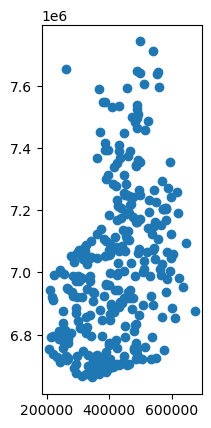

In [11]:
gauges.plot()

In [12]:
coords = np.column_stack((gauges.geometry.x, gauges.geometry.y))

# Compute distance matrix (Euclidean distance)
distance_matrix = cdist(coords, coords, metric='euclidean')

# Convert to a pandas DataFrame for better readability (optional)
distance_df = pd.DataFrame(distance_matrix, index=gauges.gauge_id, columns=gauges.gauge_id)


In [13]:
distance_df

gauge_id,2739,2740,3727,3728,1351,1354,1355,1356,1352-1358,1372,...,3907,3004,3524,3850,3006,3264,1390,938,952,972
gauge_id,,,,,,,,,,,,,,,,,,,,,
2739,0.000000,15781.859182,153459.385284,151788.245081,42051.844848,28753.216098,12375.284974,33420.191046,36080.060911,124634.953265,...,811384.214395,830149.005095,846995.469486,750133.543690,831148.595529,793859.410567,275444.491086,497000.062372,510146.475463,654084.438966
2740,15781.859182,0.000000,139065.666834,137331.568946,56851.184696,43379.253393,27989.928896,19847.351262,41317.080811,109200.638830,...,795681.610262,814967.931048,831720.432653,736620.376177,815971.104923,779243.551595,278682.061074,482928.436329,496403.529470,641208.999191
3727,153459.385284,139065.666834,0.000000,2222.737696,195507.962037,182141.230505,165646.957658,120039.286811,148220.799115,40333.250558,...,666416.370519,678198.196694,695614.767512,598464.077431,679177.852882,640430.536043,381734.006579,343962.387340,357901.814807,504955.150528
3728,151788.245081,137331.568946,2222.737696,0.000000,193830.861874,180451.287255,163995.279378,118369.266071,146943.398479,38112.154304,...,667456.494559,679632.717554,697003.571233,600367.221147,680614.153288,642077.642222,379516.286299,345766.098124,359781.422476,506963.737125
1351,42051.844848,56851.184696,195507.962037,193830.861874,0.000000,13476.189236,30008.174446,75469.606331,62458.482168,165938.048367,...,851457.419137,871804.550362,888514.423807,791887.646225,872808.742421,835890.831545,254320.182188,539008.003767,552036.578350,695390.227087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3264,793859.410567,779243.551595,640430.536043,642077.642222,835890.831545,822488.291869,806072.473881,760443.590188,785873.973759,671781.690109,...,227649.696903,95478.569323,119978.086749,126761.500236,95295.633688,0.000000,969026.413520,301035.773622,294343.305852,214657.207659
1390,275444.491086,278682.061074,381734.006579,379516.286299,254320.182188,258901.478527,270884.446059,295021.946923,309937.968216,341420.574810,...,925663.261667,982399.756769,993961.387580,953844.110828,983539.783283,969026.413520,0.000000,697613.365483,716875.915762,871329.171152
938,497000.062372,482928.436329,343962.387340,345766.098124,539008.003767,525750.170628,509020.701685,463652.639958,486683.030880,378171.074844,...,389216.078933,354389.484325,375689.875962,257214.562581,355174.747413,301035.773622,697613.365483,0.000000,25623.241403,178007.582423


In [14]:
find_n_closest_points(distance_df, '1117', 5, subset_indices=['1114', '1116', '896'])

gauge_id
1114     23353.357360
1116     25879.509269
896     461964.546800
Name: 1117, dtype: float64

In [15]:
# Getting the gauges with indice time series under 10 years
short_indices = list(hydro[hydro['sign_number_of_years'] < 10].index)
medium_indices = list(hydro[(hydro['sign_number_of_years'] >= 10) & (hydro['sign_number_of_years'] < 20)].index)
long_indices = list(hydro[hydro['sign_number_of_years'] >= 20].index)

In [16]:
print(len(medium_indices))

47


In [17]:
reg_levels = [1, 2, 3]
# Getting the gauges of different regulation levels
gauges_by_regul = {level:list(human[human['regulation_level']==level].index) for level in reg_levels}
# simplifying so that no regulation and light regulation are compared to each other
gauges_by_regul[1] += gauges_by_regul[2]
gauges_by_regul[2] += gauges_by_regul[1]

In [18]:
regions = [1, 2, 3]
gauges_by_region = {region:list(meta[meta['water_region_code']==region].index) for region in regions}

In [27]:

gauge_vs_subset = pd.DataFrame(index=hydro_comparison.columns, columns=short_indices)
subset_internal = pd.DataFrame(index=hydro_comparison.columns, columns=short_indices)
for gauge in short_indices:
    # Getting the regulation level
    regul_level = human.at[gauge, 'regulation_level']
    region = meta.at[gauge, 'water_region_code']
    # Getting the gauges that are in the same region and regulation level and have long timeseries (intersection)
    comparison_pool = list(set(gauges_by_regul[regul_level]) & set(gauges_by_region[region]) & set(long_indices))
    # Fetching the closest gauges in teh same region
    closest = find_n_closest_points(distance_df, gauge, 5, subset_indices=comparison_pool)
    closest_gauges = list(closest.index)
    comparison = compare_point_vs_subset_variation(hydro_comparison, gauge, closest_gauges)
    # Variance between the short time se
    gauge_vs_subset.loc[:, gauge] = comparison['Point vs Subset']
    subset_internal.loc[:, gauge] = comparison['Subset Internal']

In [28]:
gauge_vs_subset

,929,930,981,1009,1014,1078,1080,1104,1119,1156,...,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
q_mean,0.183811,0.127867,0.042622,0.057764,0.064187,0.107657,0.054924,0.075211,0.151789,0.048888,...,0.090921,0.104833,0.085946,0.078081,0.125605,0.350067,0.463411,0.164803,0.227721,0.134561
runoff_ratio,0.083825,0.057417,0.013292,0.030332,0.03656,0.070828,0.031411,0.032042,0.094956,0.020656,...,0.041673,0.067132,0.045898,0.037639,0.055377,0.234471,0.243447,0.111654,0.138996,0.064317
stream_elas,0.335619,0.401368,0.286054,0.341155,0.21997,0.298038,0.274329,1.023106,0.613927,0.486621,...,0.276815,1.024254,0.429092,0.297187,0.332305,0.493697,0.098675,0.231402,0.28117,0.411845
slope_fdc,5.319765,0.580655,0.500856,0.358422,0.34322,2.181611,1.976621,0.672733,1.265601,0.224291,...,0.650292,1.43684,0.171192,1.120494,1.183798,0.784449,0.7264,2.195639,1.282809,2.039092
baseflow_index,0.194053,0.056451,0.08165,0.08792,0.087864,0.110348,0.076942,0.142922,0.097912,0.056451,...,0.147739,0.131567,0.099398,0.0392,0.188936,0.100333,0.080602,0.09331,0.084538,0.095499
hfd_mean,12.355612,8.315391,9.344711,4.025423,9.146411,6.159364,9.727512,8.116417,10.483319,4.936294,...,12.686007,13.220866,13.147734,2.996671,12.255713,21.745715,19.985454,6.351955,7.22523,9.785384
Q5,0.115355,0.090277,0.083905,0.087178,0.114091,0.122583,0.041191,0.104003,0.04858,0.033267,...,0.142326,0.090203,0.047329,0.017224,0.056006,0.174518,0.15824,0.11003,0.047924,0.045789
Q95,0.755584,0.504965,0.444777,0.314372,0.293627,0.300067,0.229172,0.797086,0.445197,0.392059,...,0.274056,0.355495,0.613365,0.507136,0.882224,1.142815,0.75312,0.590268,0.869814,0.601811
high_q_freq,8.952885,4.726795,3.053787,0.0,0.0,18.605763,16.386768,20.688875,16.23981,2.191316,...,0.0,19.913057,1.054964,7.249515,17.495053,4.416151,4.416151,18.433428,13.851209,18.52903
high_q_dur,1.188003,3.075122,5.152598,0.0,0.0,1.833779,1.021737,3.538738,0.841509,4.302928,...,0.0,8.760184,1.745254,0.812816,3.008991,3.322443,3.322443,1.898214,1.031904,2.734328


In [29]:
subset_internal

,929,930,981,1009,1014,1078,1080,1104,1119,1156,...,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
q_mean,0.172714,0.142934,0.027019,0.063797,0.063797,0.064962,0.0614,0.083845,0.042426,0.036056,...,0.094868,0.107564,0.09094,0.080498,0.136748,0.023022,0.023022,0.139392,0.042426,0.139392
runoff_ratio,0.07733,0.06229,0.014142,0.033912,0.033912,0.036469,0.035071,0.035777,0.0251,0.014142,...,0.043243,0.066558,0.045497,0.039115,0.060581,0.008944,0.008944,0.066106,0.0251,0.066106
stream_elas,0.159625,0.248938,0.266308,0.245255,0.245255,0.19995,0.209881,0.384838,0.276912,0.485026,...,0.211021,0.555455,0.315389,0.2498,0.264329,0.098234,0.098234,0.186869,0.276912,0.186869
slope_fdc,5.732918,0.531724,0.35433,0.379803,0.379803,2.212797,2.114143,0.403856,1.404539,0.248093,...,0.6998,0.798455,0.185876,1.249148,1.263123,0.810907,0.810907,2.20628,1.404539,2.20628
baseflow_index,0.192795,0.058481,0.066933,0.08792,0.08792,0.110995,0.085323,0.13813,0.084676,0.055946,...,0.16453,0.088148,0.110589,0.03,0.210666,0.083546,0.083546,0.095499,0.084676,0.095499
hfd_mean,13.687271,9.00918,4.930968,4.247464,4.247464,6.868316,4.101581,6.099504,5.226847,2.381243,...,10.279638,10.203992,13.934923,3.072291,13.370951,12.79855,12.79855,7.092542,5.226847,7.092542
Q5,0.106301,0.086487,0.061074,0.093541,0.093541,0.044497,0.040988,0.1,0.053198,0.036469,...,0.158367,0.072319,0.052631,0.018708,0.061482,0.174786,0.174786,0.048166,0.053198,0.048166
Q95,0.799769,0.492169,0.251396,0.327063,0.327063,0.310934,0.24077,0.806207,0.38766,0.315801,...,0.305008,0.331014,0.681564,0.470872,0.976806,0.445062,0.445062,0.656186,0.38766,0.656186
high_q_freq,9.807394,4.273938,3.256698,0.0,0.0,19.7185,17.809294,22.646927,14.046397,2.253903,...,0.0,0.95429,1.125336,3.838489,19.461991,4.713587,4.713587,19.50581,14.046397,19.50581
high_q_dur,1.301392,1.899834,5.467461,0.0,0.0,1.958576,1.140228,3.779947,0.939186,4.491495,...,0.0,4.80029,1.851405,0.6416,2.082827,2.558554,2.558554,1.448627,0.939186,1.448627


In [30]:
results = pd.DataFrame(index=hydro_comparison.columns, columns = ['vs', 'internal','mean_diff_of_std','t-statistic', 'p-value'])
for indice in hydro_comparison.columns:
    test_result = stats.ttest_ind(list(gauge_vs_subset.loc[indice]), list(subset_internal.loc[indice]), equal_var=False, alternative='greater')
    results.loc[indice, 'vs'] = gauge_vs_subset.loc[indice].mean()
    results.loc[indice, 'internal'] = subset_internal.loc[indice].mean()
    results.loc[indice, 'mean_diff_of_std'] = gauge_vs_subset.loc[indice].mean() - subset_internal.loc[indice].mean()
    results.loc[indice, 't-statistic'] = test_result.statistic
    results.loc[indice, 'p-value'] = test_result.pvalue

In [31]:
results

,vs,internal,mean_diff_of_std,t-statistic,p-value
q_mean,0.133324,0.084072,0.049252,2.640834,0.005571
runoff_ratio,0.074756,0.041468,0.033288,2.963945,0.002489
stream_elas,0.361849,0.256299,0.10555,2.521022,0.007294
slope_fdc,0.944641,0.900496,0.044145,0.188923,0.425352
baseflow_index,0.099077,0.093303,0.005774,0.627559,0.266169
hfd_mean,12.008424,8.684368,3.324056,2.138049,0.018677
Q5,0.08472,0.076815,0.007904,0.722981,0.236056
Q95,0.586108,0.533646,0.052462,1.031252,0.153008
high_q_freq,8.242796,7.892368,0.350429,0.208888,0.417572
high_q_dur,2.600813,2.242074,0.358739,1.018063,0.156201


In [32]:
results['vs'] / results['internal']

q_mean            1.585823
runoff_ratio      1.802728
stream_elas       1.411823
slope_fdc         1.049023
baseflow_index    1.061884
hfd_mean          1.382763
Q5                  1.1029
Q95               1.098309
high_q_freq       1.044401
high_q_dur        1.160003
low_q_freq        1.091724
low_q_dur         1.049753
zero_q_freq       1.168926
dtype: object

## all positive values of mean_diff_of_std mean that on average, gauges with short time series (< 5 years) differ significantly more from nearby similar gauges than those nearby gauges differ from each other

# Running the same comparison between medium and long time series

In [33]:
gauge_vs_subset = pd.DataFrame(index=hydro_comparison.columns, columns=medium_indices)
subset_internal = pd.DataFrame(index=hydro_comparison.columns, columns=medium_indices)
for gauge in medium_indices:
    # Getting the regulation level
    regul_level = human.at[gauge, 'regulation_level']
    region = meta.at[gauge, 'water_region_code']
    # Getting the gauges that are in the same region and regulation level and have long timeseries (intersection)
    comparison_pool = list(set(gauges_by_regul[regul_level]) & set(gauges_by_region[region]) & set(long_indices))
    # Fetching the closest gauges in teh same region
    closest = find_n_closest_points(distance_df, gauge, 5, subset_indices=comparison_pool)
    closest_gauges = list(closest.index)
    comparison = compare_point_vs_subset_variation(hydro_comparison, gauge, closest_gauges)
    # Variance between the short time se
    gauge_vs_subset.loc[:, gauge] = comparison['Point vs Subset']
    subset_internal.loc[:, gauge] = comparison['Subset Internal']

results = pd.DataFrame(index=hydro_comparison.columns, columns = ['vs','internal', 'mean_diff_of_std','t-statistic', 'p-value'])
for indice in hydro_comparison.columns:
    test_result = stats.ttest_ind(list(gauge_vs_subset.loc[indice]), list(subset_internal.loc[indice]), equal_var=False, alternative='greater')
    results.loc[indice, 'vs'] = gauge_vs_subset.loc[indice].mean()
    results.loc[indice, 'internal'] = subset_internal.loc[indice].mean()
    results.loc[indice, 'mean_diff_of_std'] = gauge_vs_subset.loc[indice].mean() - subset_internal.loc[indice].mean()
    results.loc[indice, 't-statistic'] = test_result.statistic
    results.loc[indice, 'p-value'] = test_result.pvalue
results

,vs,internal,mean_diff_of_std,t-statistic,p-value
q_mean,0.119599,0.10114,0.018459,1.620943,0.054468
runoff_ratio,0.059488,0.049847,0.009641,1.680271,0.048604
stream_elas,0.302982,0.262732,0.04025,1.877784,0.0319
slope_fdc,0.776287,0.738525,0.037762,0.357054,0.360941
baseflow_index,0.087492,0.087775,-0.000283,-0.041967,0.516692
hfd_mean,9.879376,7.939687,1.939689,1.918527,0.029108
Q5,0.077659,0.071038,0.006621,1.240398,0.10909
Q95,0.544563,0.517048,0.027515,0.618132,0.269009
high_q_freq,6.845465,6.913802,-0.068337,-0.055331,0.522002
high_q_dur,2.551472,2.309129,0.242343,1.050867,0.148042


## Medium timeseries (10-20 years) differ also more from long timeseries than long timeseries among themselves, however the variation is consistently smaller than for the shorter

In [26]:
results['vs'] / results['internal']

q_mean            1.182508
runoff_ratio      1.193408
stream_elas       1.153197
slope_fdc         1.051131
baseflow_index    0.996781
hfd_mean          1.244303
Q5                1.093203
Q95               1.053215
high_q_freq       0.990116
high_q_dur         1.10495
low_q_freq        0.993404
low_q_dur         1.037167
zero_q_freq       1.308024
dtype: object

In [44]:
comparison_pool

['1163',
 '3542',
 '3260',
 '1287',
 '1015',
 '1307',
 '1003',
 '951',
 '937',
 '1018',
 '1314',
 '1019',
 '1030',
 '924',
 '3602',
 '929',
 '1157',
 '1283',
 '1305',
 '1024',
 '1147',
 '1008',
 '1052',
 '1313',
 '1166',
 '1160',
 '1053',
 '1056',
 '3155',
 '1187',
 '980',
 '1303',
 '3033',
 '1188',
 '964',
 '1012',
 '1136',
 '1158',
 '1174',
 '1060',
 '1312',
 '1055',
 '985',
 '1137',
 '941',
 '946',
 '935',
 '3605',
 '1140',
 '1178',
 '961',
 '1014',
 '1045',
 '984',
 '1050',
 '1057',
 '1046',
 '1171',
 '1310',
 '939',
 '996',
 '1308',
 '943',
 '1021',
 '1009',
 '1148',
 '1058',
 '1048']